# Experiment 11: Hypothesis Testing — One-Sample Z-Test on Diabetes Dataset

**AIM:**  
To perform a One-Sample Z-Test on the Glucose level of the UCI Diabetes dataset to test whether the sample mean significantly differs from a hypothesized population mean ($\mu_0 = 100$) using `statsmodels` and visualize rejection boundaries.

**SOFTWARE REQUIREMENTS:**  
- **Python**: Version 3.13.x  
- **Jupyter Notebook**: Version 7.x  
- **Packages**: NumPy, Pandas, Statsmodels, SciPy, Matplotlib  

---
### THEORY:
- **One-Sample Z-Test**: A parametric statistical test used to determine whether the mean of a single sample differs significantly from a known or hypothesized population mean when sample size is large ($n \ge 30$):
  $$Z = \frac{\bar{X} - \mu_0}{\sigma / \sqrt{n}}$$
- **Hypotheses**:
  - **Null Hypothesis ($H_0$)**: $\mu = 100$ (The true mean Glucose level is equal to 100).
  - **Alternative Hypothesis ($H_1$)**: $\mu \neq 100$ (The true mean Glucose level differs significantly from 100).
- **Decision Rule**: Reject $H_0$ if $p < \alpha$ (where $\alpha = 0.05$) or $|Z| > 1.96$.

---
### PROCEDURE:
1. Load the UCI Diabetes Dataset (`uci_diabetes.csv`).
2. Extract the continuous `Glucose` feature and compute sample statistics ($n, \bar{X}, s$).
3. Perform the two-tailed One-Sample Z-Test using `ztest` from `statsmodels.stats.weightstats`.
4. Compare the computed p-value against the significance threshold $\alpha = 0.05$.
5. Plot the Standard Normal distribution with critical rejection regions and the observed test statistic.

## 1. Import Libraries & Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from statsmodels.stats.weightstats import ztest

uci_diabetes = pd.read_csv('uci_diabetes.csv')
print('UCI Diabetes Dataset loaded successfully!')
print(uci_diabetes.head())

UCI Diabetes Dataset loaded successfully!
   Pregnancies  Glucose  BloodPressure  ...  DiabetesPedigreeFunction  Age  Outcome
0            6       98             58  ...                     0.430   43        0
1            2      112             75  ...                     0.148   21        0
2            2      108             64  ...                     0.158   21        0
3            8      107             80  ...                     0.856   34        0
4            7      136             90  ...                     0.210   50        0

[5 rows x 9 columns]


## 2. Hypothesis Formulation & Z-Test Computation

In [2]:
glucose = uci_diabetes['Glucose'].dropna()
hypothesized_mean = 100
sample_mean = glucose.mean()
sample_std = glucose.std()
n = len(glucose)

print(f'Sample Size (N): {n}')
print(f'Sample Mean Glucose: {sample_mean:.4f}')
print(f'Sample Std Dev: {sample_std:.4f}')
print(f'Hypothesized Population Mean (μ0): {hypothesized_mean}')

# H0: μ = 100 vs H1: μ != 100
z_stat, p_value = ztest(glucose, value=hypothesized_mean)
alpha = 0.05

print('\n--- Z-TEST RESULTS ---')
print(f'Z-Statistic: {z_stat:.4f}')
print(f'P-Value: {p_value:.6f}')
print(f'Significance Level (α): {alpha}')

if p_value < alpha:
    print('Conclusion: Reject the Null Hypothesis (H0). The sample mean Glucose level differs significantly from 100.')
else:
    print('Conclusion: Fail to Reject the Null Hypothesis (H0). There is no significant difference from 100.')

Sample Size (N): 100
Sample Mean Glucose: 119.9500
Sample Std Dev: 31.3773
Hypothesized Population Mean (μ0): 100

--- Z-TEST RESULTS ---
Z-Statistic: 6.3581
P-Value: 0.000000
Significance Level (α): 0.05
Conclusion: Reject the Null Hypothesis (H0). The sample mean Glucose level differs significantly from 100.


## 3. Standard Normal Distribution & Critical Rejection Boundaries

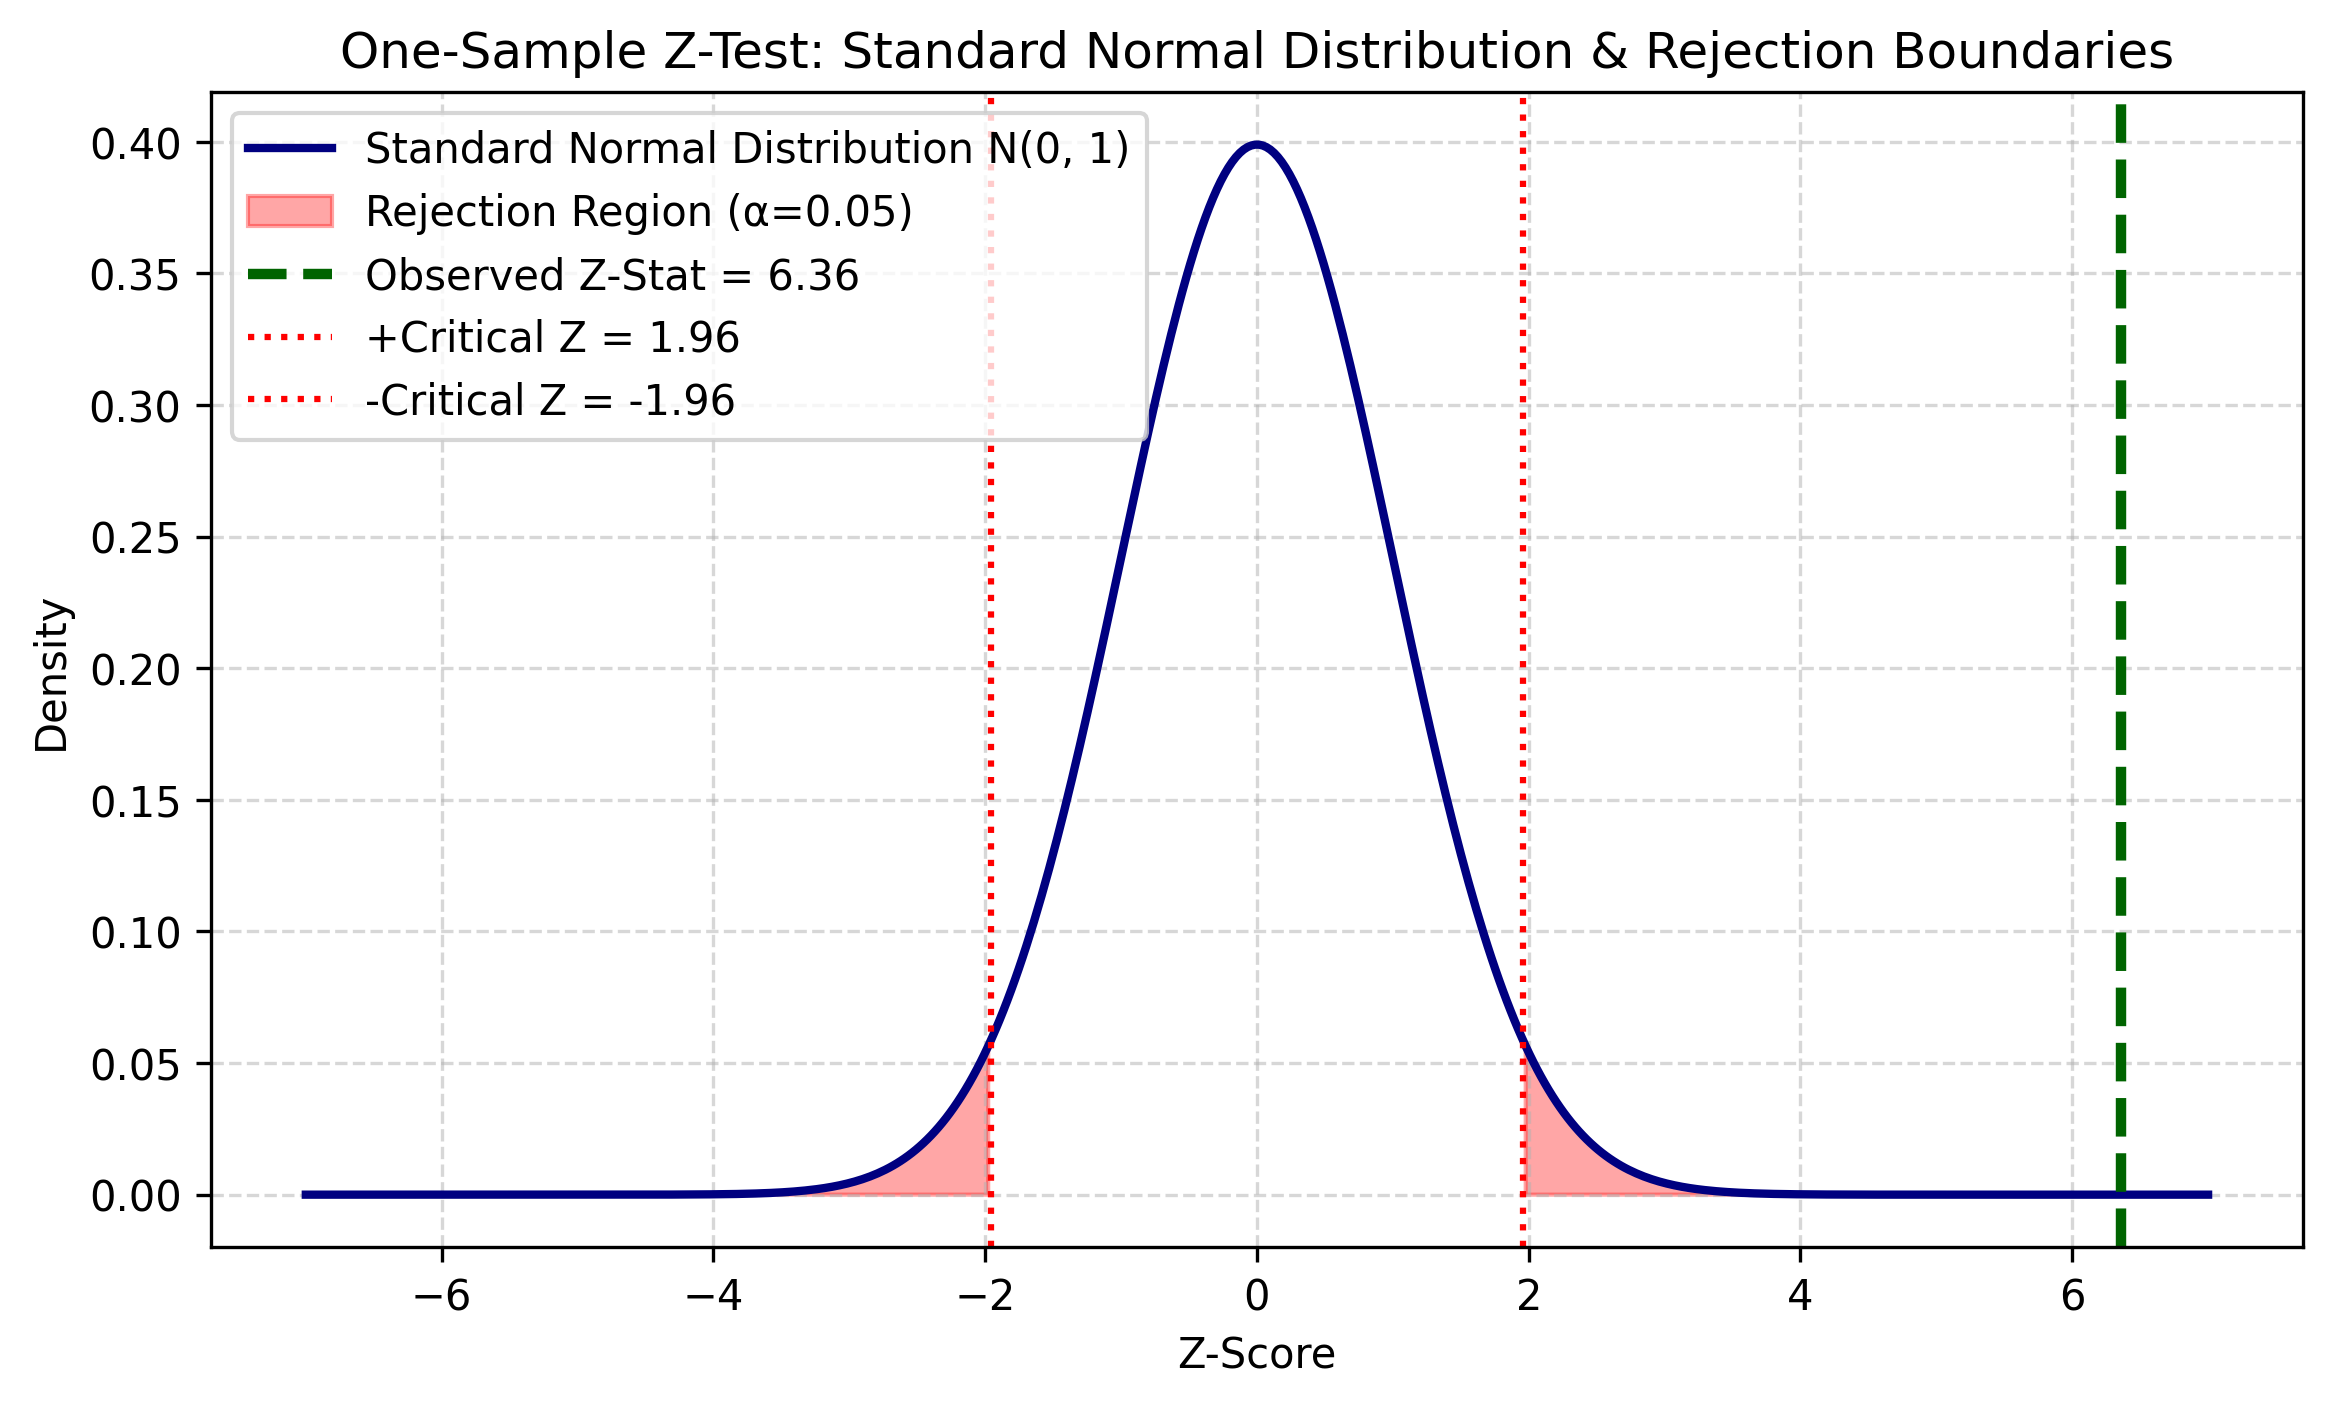

In [3]:
x = np.linspace(-7, 7, 500)
y = norm.pdf(x, 0, 1)
z_crit = norm.ppf(1 - alpha/2)

plt.figure(figsize=(9, 5))
plt.plot(x, y, label='Standard Normal Distribution N(0, 1)', color='navy', lw=2)
plt.fill_between(x, y, where=(x >= z_crit) | (x <= -z_crit), color='red', alpha=0.35, label=f'Rejection Region (α={alpha})')
plt.axvline(z_stat, color='darkgreen', linestyle='--', lw=2.5, label=f'Observed Z-Stat = {z_stat:.2f}')
plt.axvline(z_crit, color='red', linestyle=':', lw=1.5, label=f'+Critical Z = {z_crit:.2f}')
plt.axvline(-z_crit, color='red', linestyle=':', lw=1.5, label=f'-Critical Z = -{z_crit:.2f}')
plt.title('One-Sample Z-Test: Standard Normal Distribution & Rejection Boundaries')
plt.xlabel('Z-Score')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()